In [1]:
# Terrible hackiness while I work on the tutorial; clean this up before releasing!
import os
import sys
parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)


In [2]:
from datautils import db_utils
from datautils.radar_utils import RadarData

In [3]:
import sqlite3

In [4]:
root_dir = "/Users/lindzey/RadarData/test_download"
index_filepath = "/Users/lindzey/Documents/QIceRadar/code/radar_wrangler/indices/qiceradar_antarctic_index.gpkg"


In [5]:
def load_data(granule_name: str) -> RadarData:
    connection = sqlite3.connect(index_filepath)
    cursor = connection.cursor()

    # TODO: Need to raise an informative exception here indicating that granule_name is invalid. (Or at least, not in the index.)
    sql_cmd = f"SELECT * FROM granules where name is '{granule_name}'"
    result = cursor.execute(sql_cmd)
    rows = result.fetchall()
    db_granule = db_utils.DatabaseGranule(*rows[0])

    data = RadarData(db_granule, os.path.join(root_dir, db_granule.relative_path))
    return data

In [6]:
cresis_granule = "CRESIS_2022_Antarctica_BaslerMKB_20230110_01_015"
data = load_data(cresis_granule)

load_radargram(/Users/lindzey/RadarData/test_download/ANTARCTIC/CRESIS/2022_Antarctica_BaslerMKB/CSARP_standard/20230110_01/Data_20230110_01_015.mat)


In [12]:
import matplotlib.pyplot as plt
import numpy as np

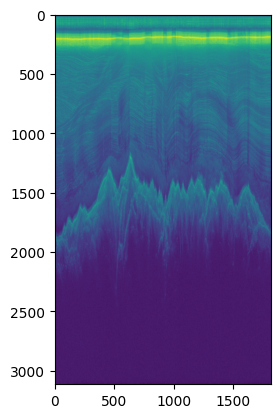

In [14]:
# This plots the radargram with "traces" on the X-axis and "samples" on the Y-axis
plt.imshow(np.transpose(data.data))

In [21]:
# This extracts the radargram flight paths and plots them in PS71 on a map of Antarctica
fig = plt.Figure()
ax = fig.add_axes([0,0,1,1])
ax.plot(data.xx, data.yy, 'k.')
plt.show()
#print(data.xx)
#dir(data)

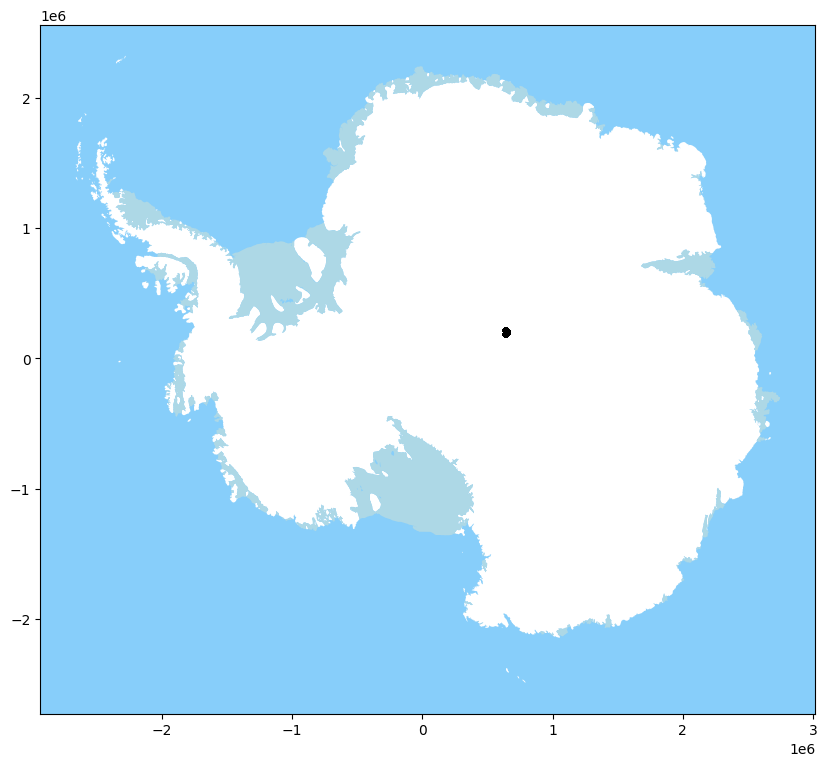

In [ ]:
# Plot simple Antarctic basemap, from Quantarctica
import geopandas as gpd
basemap_path = "~/ADATA/Quantarctica/Quantarctica3/Miscellaneous/SimpleBasemap/ADD_DerivedLowresBasemap.shp"
gdf = gpd.read_file(basemap_path)
# gdf.plot()
fig, ax = plt.subplots(figsize=[10, 10])
ax.set_facecolor('lightskyblue')

land_gdf = gdf[gdf['Category'] == 'Land']
shelf_gdf = gdf[gdf['Category'] == 'Ice shelf']
land_gdf.plot(ax=ax, facecolor='white')
shelf_gdf.plot(ax=ax, facecolor='lightblue')

# Plot the PS71 coordinates of our selected granule:
plt.plot(data.xx, data.yy, 'k.')

#

(-3333500.0, 3333500.0, -3333500.0, 3333500.0)


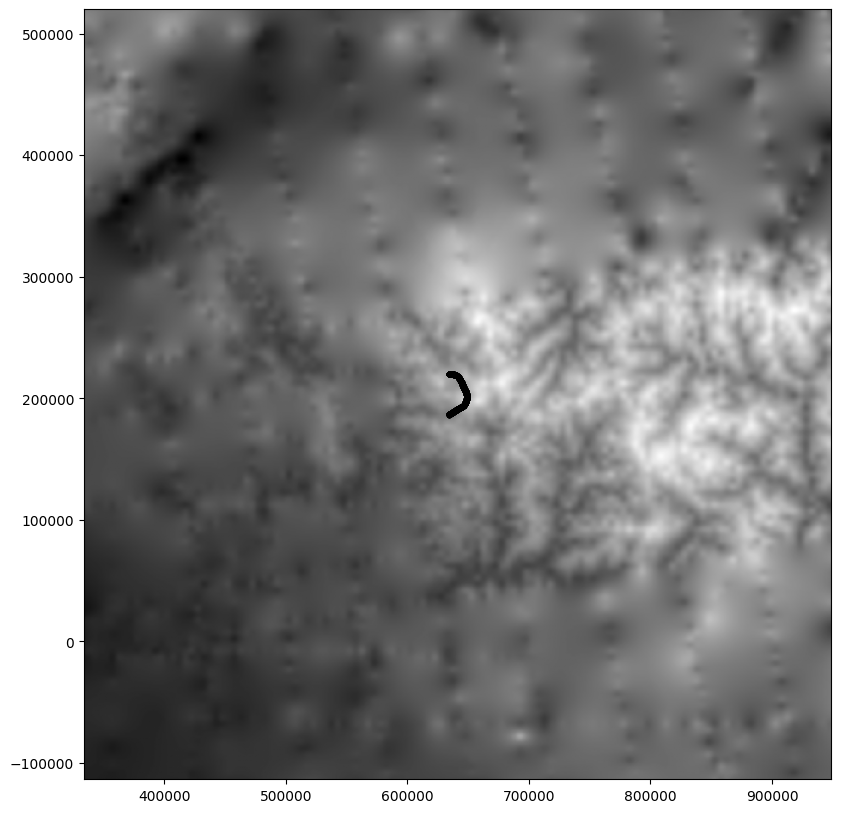

In [ ]:
import rasterio
import rasterio.plot
import rasterio.windows

# Zoom in to a region around the granule's flight path, and plot it on top of the bedmap data
margin = 300000 # in meters
minx = min(data.xx) - margin
maxx = max(data.xx) + margin
miny = min(data.yy) - margin
maxy = max(data.yy) + margin

bedmap_path = "/Users/lindzey/ADATA/Quantarctica/Quantarctica3/TerrainModels/BEDMAP2/bedmap2_bed.tif"
with rasterio.open(bedmap_path) as src:

    bedmap_data = src.read(1)
    extent = rasterio.plot.plotting_extent(src)

    window = rasterio.windows.from_bounds(minx, miny, maxx, maxy, transform=src.transform)
    bedmap_subset = src.read(1, window=window)

fig, ax = plt.subplots(figsize=[10, 10])
plt.imshow(bedmap_subset, cmap='grey', extent=[minx, maxx, miny, maxy], vmin=bedmap_subset.min(), vmax=bedmap_subset.max())
plt.plot(data.xx, data.yy, 'k.')
ax.set_xlim([minx, maxx])
ax.set_ylim([miny, maxy])

print(extent)